In [1]:
import pandas as pd

# 데이터 로드
df = pd.read_csv('wine.csv')

# 상위 5개 샘플 확인
df.head()


,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


wine.csv 파일은 컬럼명이 포함되지 않은 상태로 되어 있으며, 첫 번째 열이 잘못된 방식으로 인덱스 처리되어 있음. 

따라서 데이터 전처리를 시작으로 데이터 사이언스 프로세스 진행 

# Step 1: 데이터 수집 및 정리

In [2]:
# 컬럼명 정의
columns = [
    'Class label', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash',
    'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
    'Proanthocyanins', 'Color intensity', 'Hue',
    'OD280/OD315 of diluted wines', 'Proline'
]

# 2. 파일 재로딩 및 컬럼명 적용
df = pd.read_csv('wine.csv', header=None, names=columns)

# 3. 데이터 프레임 상위 5개 행 확인
df.head()


,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


---

# Step 2 – 데이터 가공

In [3]:
from sklearn.preprocessing import StandardScaler

# Step 2-1: 결측치 확인
missing_values = df.isnull().sum()

missing_values

Class label                     0
Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
dtype: int64

데이터는 매우 정제된 상태이며, 추가적인 결측치 처리가 불필요

In [4]:
# Step 2-2: 클래스 분포 확인
class_distribution = df['Class label'].value_counts()

class_distribution

2    71
1    59
3    48
Name: Class label, dtype: int64

세 클래스 모두 비교적 균형 잡힌 분포를 가지고 있어 분류 문제에 적합한 데이터셋

In [5]:
# Step 2-3: 피처 정규화

X = df.drop('Class label', axis=1)
y = df['Class label']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 결과 출력
X_scaled[:5]


array([[ 1.51861254, -0.5622498 ,  0.23205254, -1.16959318,  1.91390522,
         0.80899739,  1.03481896, -0.65956311,  1.22488398,  0.25171685,
         0.36217728,  1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, -2.49084714,  0.01814502,
         0.56864766,  0.73362894, -0.82071924, -0.54472099, -0.29332133,
         0.40605066,  1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, -0.2687382 ,  0.08835836,
         0.80899739,  1.21553297, -0.49840699,  2.13596773,  0.26901965,
         0.31830389,  0.78858745,  1.39514818],
       [ 1.69154964, -0.34681064,  0.4879264 , -0.80925118,  0.93091845,
         2.49144552,  1.46652465, -0.98187536,  1.03215473,  1.18606801,
        -0.42754369,  1.18407144,  2.33457383],
       [ 0.29570023,  0.22769377,  1.84040254,  0.45194578,  1.28198515,
         0.80899739,  0.66335127,  0.22679555,  0.40140444, -0.31927553,
         0.36217728,  0.44960118, -0.03787401]])

모든 특성은 평균이 0, 표준편차가 1인 분포로 변환되어 모델 학습 안정성 확보

---

# Step 3 – 탐색적 데이터 분석 (EDA) 

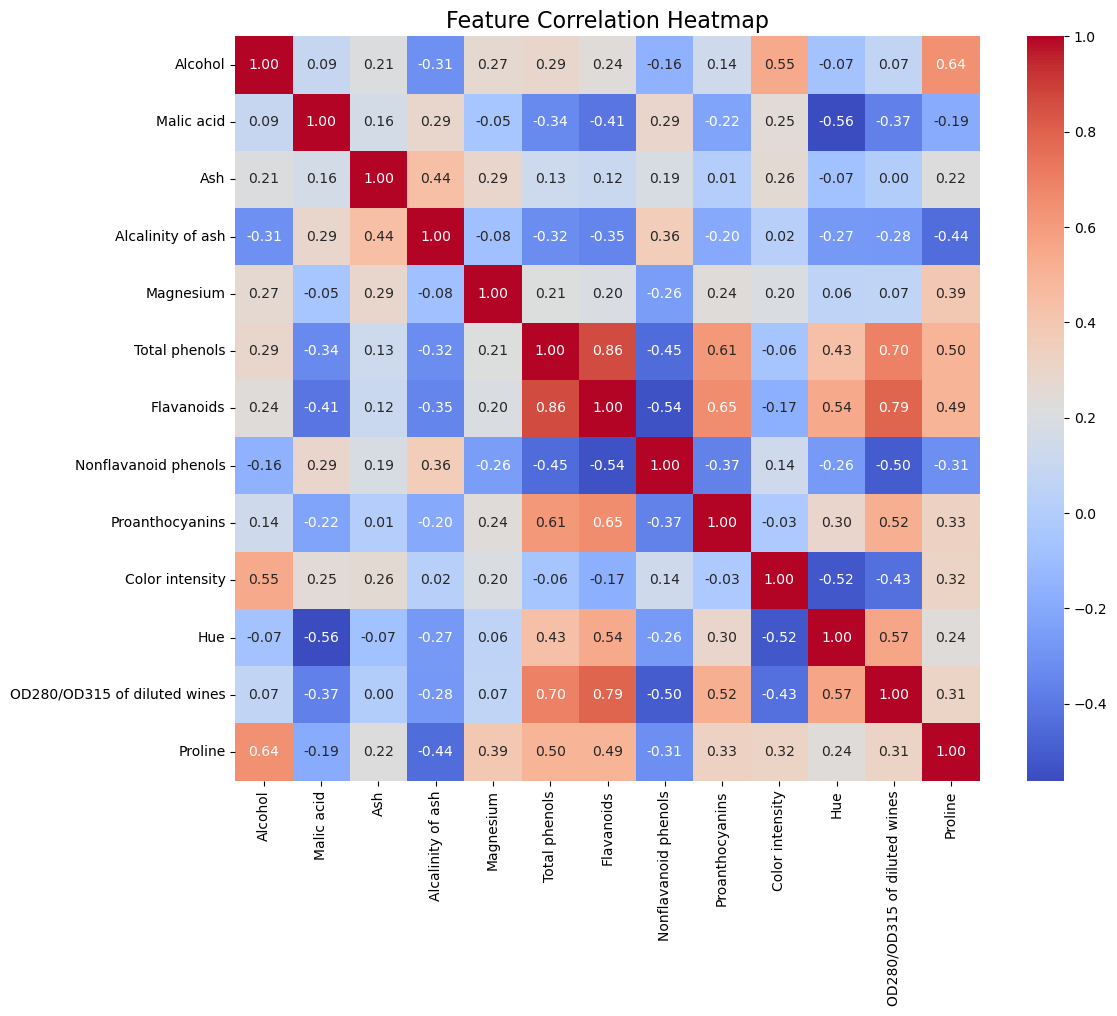

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 3-1: 상관관계 분석
correlation_matrix = df.drop('Class label', axis=1).corr()

# 시각화 설정
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()


## 주요 인사이트

- **높은 상관관계를 가지는 변수쌍**:
    - `Total phenols` ↔ `Flavanoids`: **0.86**
    - `OD280/OD315` ↔ `Flavanoids`: **0.79**
    - `Color intensity` ↔ `Hue`: **0.56**
- **음의 상관관계**:
    - `Flavanoids`와 `Nonflavanoid phenols`: **0.41**
    - `Color intensity`와 `Hue`: **0.56**

→ 이러한 변수쌍은 **모델 학습 시 중복 정보**가 될 수 있으며, **PCA나 LDA**를 적용하면 차원 축소로도 잘 반영할 수 있음

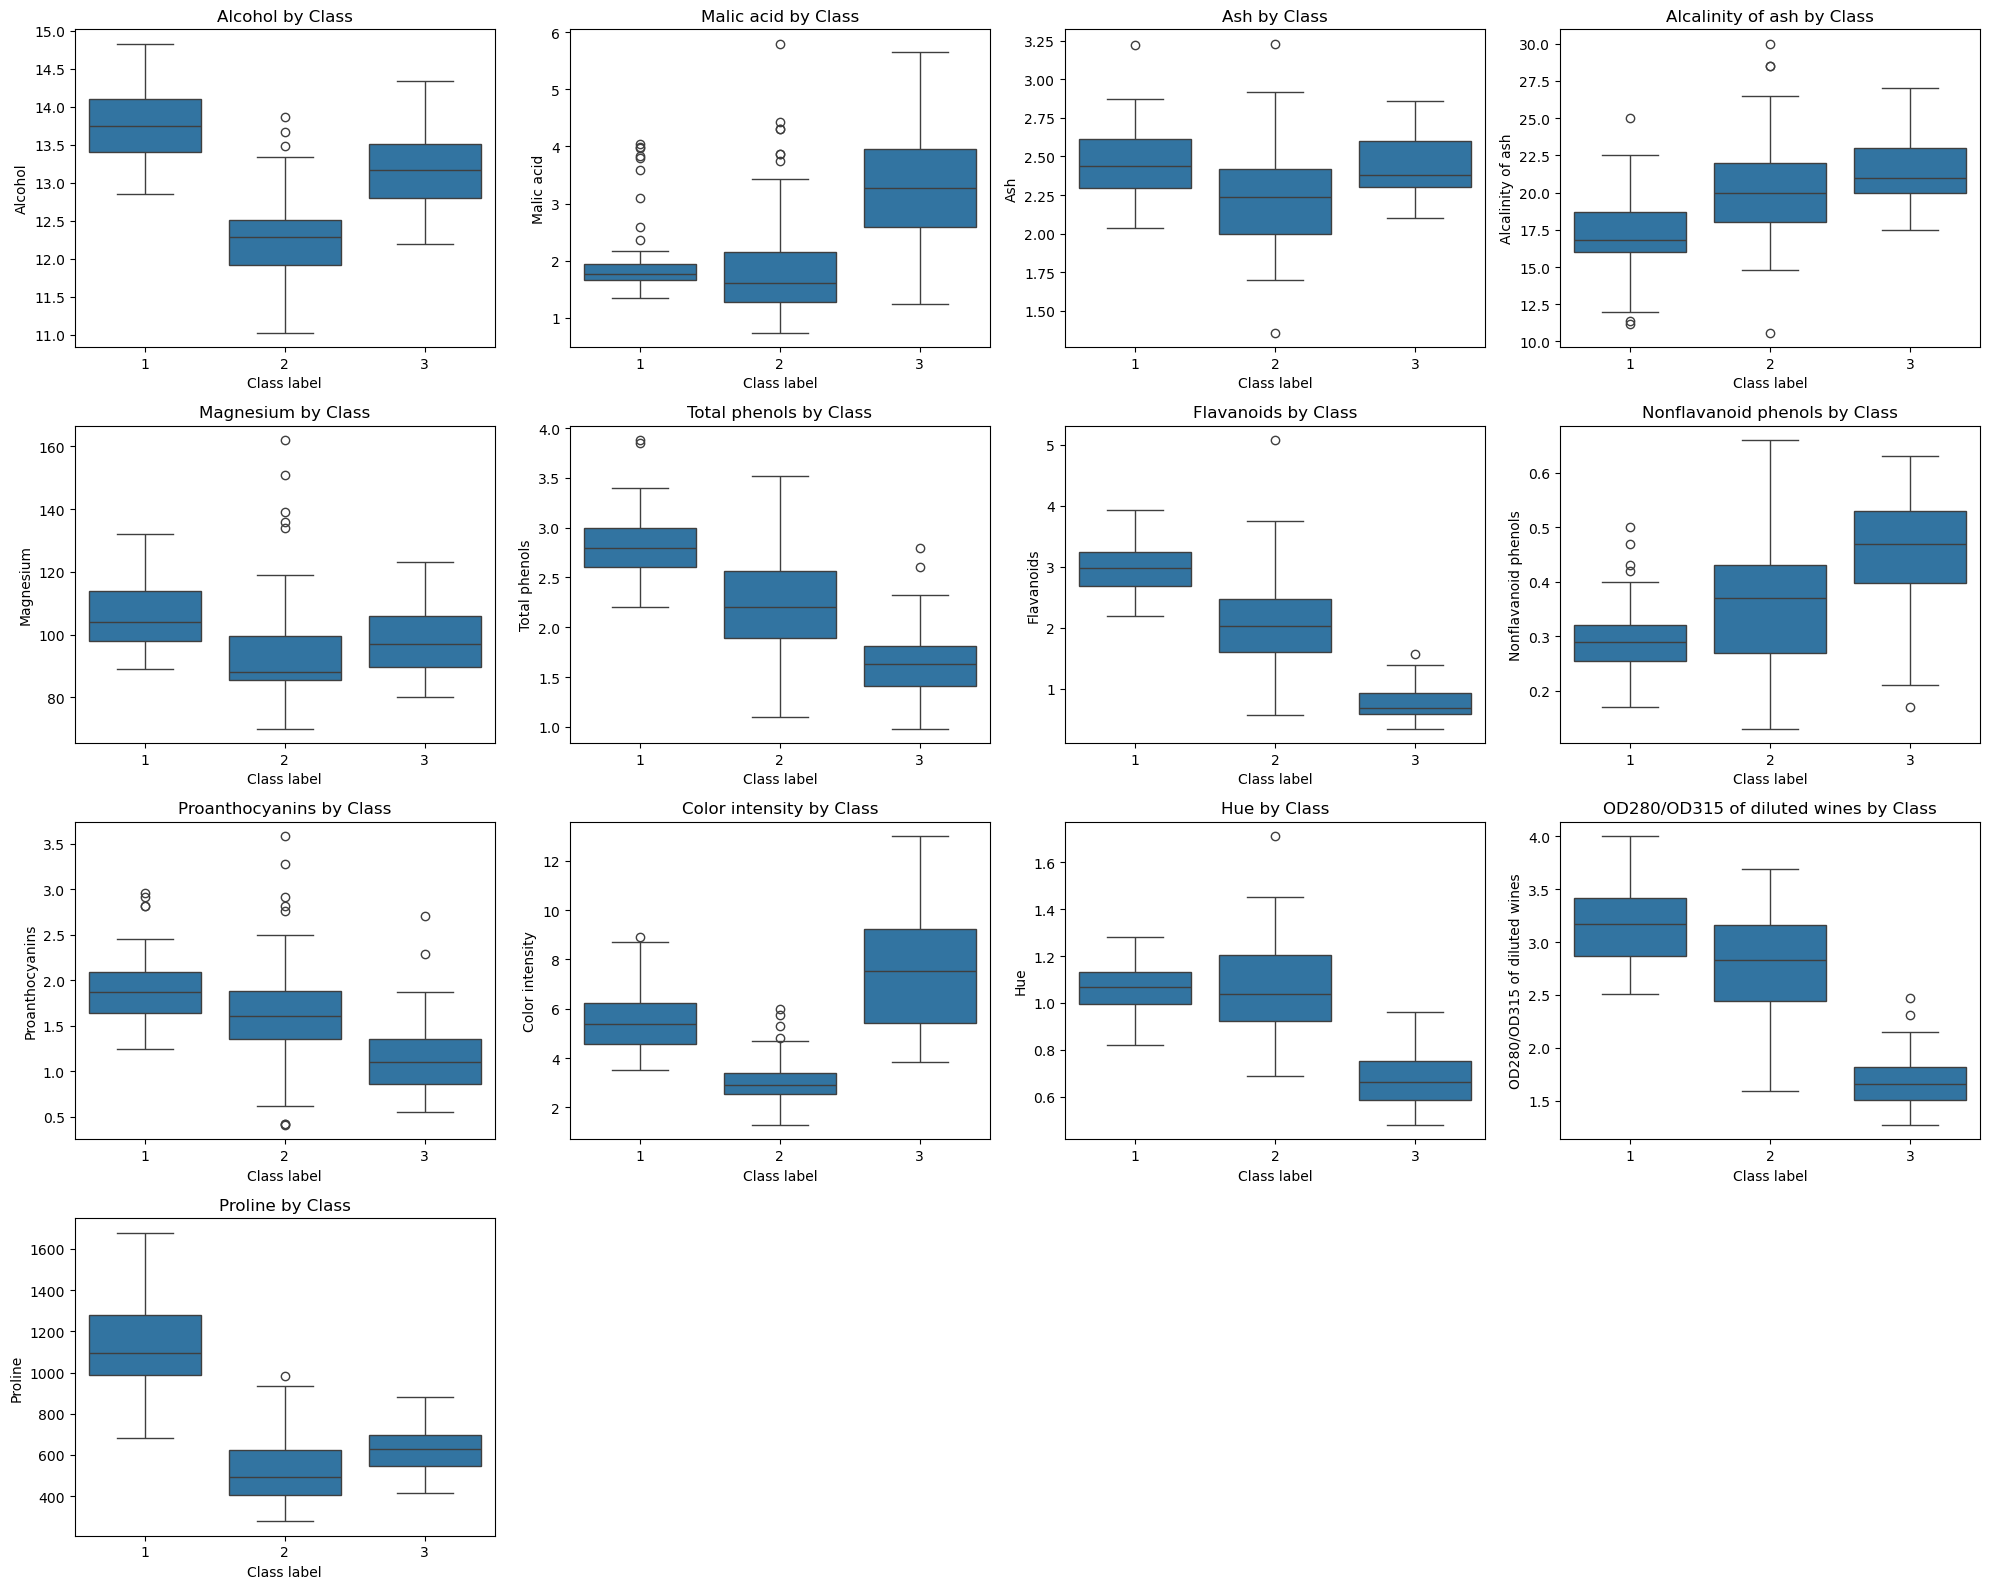

In [7]:
# Step 3-2: 클래스별 변수 분포 시각화 (박스플롯)
# 한 화면에 모든 주요 변수의 박스플롯을 출력

features = df.columns[1:]  # 'Class label' 제외
n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))

plt.figure(figsize=(20, 4 * n_rows))
for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, x='Class label', y=feature)
    plt.title(f'{feature} by Class')
    plt.xlabel('Class label')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()


## 주요 인사이트 :

| 변수 | 관찰된 특징 |
| --- | --- |
| **Alcohol** | 클래스 1이 가장 높고, 클래스 2가 가장 낮음 |
| **Flavanoids** | 클래스 1이 뚜렷하게 높은 값을 가짐 |
| **Color intensity** | 클래스 3이 월등히 높음 |
| **OD280/OD315 of diluted wines** | 클래스 1이 가장 높음 |
| **Proline** | 클래스 1 → 3 → 2 순으로 구분 가능 |

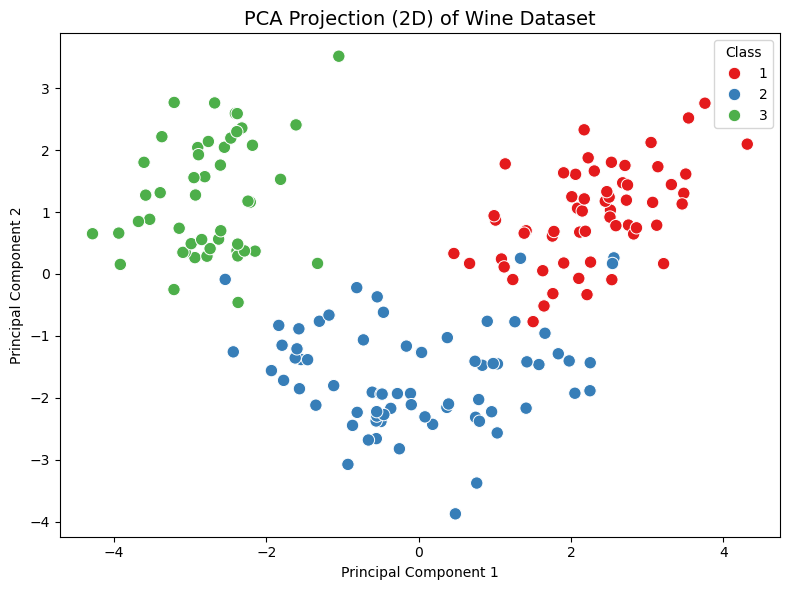

In [8]:
from sklearn.decomposition import PCA

# Step 3-3: PCA를 통한 2차원 시각화
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 시각화를 위한 데이터프레임 생성
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Class label'] = y

# 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Class label', palette='Set1', s=80)
plt.title("PCA Projection (2D) of Wine Dataset", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Class')
plt.tight_layout()
plt.show()


## 주요 인사이트

- **PC1과 PC2로 투영된 시각화**를 보면 세 클래스가 **명확히 구분되는 경향**을 보임:
    - **클래스 1**과 **클래스 3**은 거의 완전히 분리
    - **클래스 2**는 일부 클래스 1과 경계가 겹치지만, 여전히 독립적인 분포

---

# Step 4 – 모델링 시작

## Step 4-1: LDA

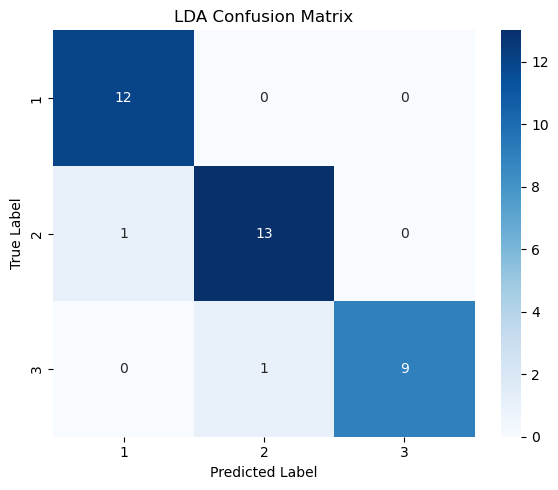

{'1': {'precision': 0.9230769230769231,
  'recall': 1.0,
  'f1-score': 0.96,
  'support': 12.0},
 '2': {'precision': 0.9285714285714286,
  'recall': 0.9285714285714286,
  'f1-score': 0.9285714285714286,
  'support': 14.0},
 '3': {'precision': 1.0,
  'recall': 0.9,
  'f1-score': 0.9473684210526315,
  'support': 10.0},
 'accuracy': 0.9444444444444444,
 'macro avg': {'precision': 0.9505494505494506,
  'recall': 0.942857142857143,
  'f1-score': 0.9453132832080201,
  'support': 36.0},
 'weighted avg': {'precision': 0.9465811965811967,
  'recall': 0.9444444444444444,
  'f1-score': 0.944269005847953,
  'support': 36.0}}

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Step 4-1: LDA 모델링

# 데이터 분할 (학습/테스트)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# LDA 모델 훈련
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# 예측
y_pred_lda = lda.predict(X_test)

# 성능 평가
conf_matrix_lda = confusion_matrix(y_test, y_pred_lda)
report_lda = classification_report(y_test, y_pred_lda, output_dict=True)

# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_lda, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3], yticklabels=[1,2,3])
plt.title("LDA Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

report_lda


## 성능 요약 (Test Set 기준)

| 클래스 | Precision | Recall | F1-score | Support |
| --- | --- | --- | --- | --- |
| **1** | 0.92 | 1.00 | 0.96 | 12 |
| **2** | 0.93 | 0.93 | 0.93 | 14 |
| **3** | 1.00 | 0.90 | 0.95 | 10 |
- **정확도 (Accuracy)**: **94.4%**
- **Macro 평균 F1-score**: **0.945**



## 해석

- **클래스 1**은 100% 완벽하게 분류됨
- **클래스 3**도 약간의 오분류만 존재함 (Recall 90%)
- **전반적으로 LDA는 이 데이터셋에서 매우 우수한 성능**을 보여줌

## Step 4-2: QDA

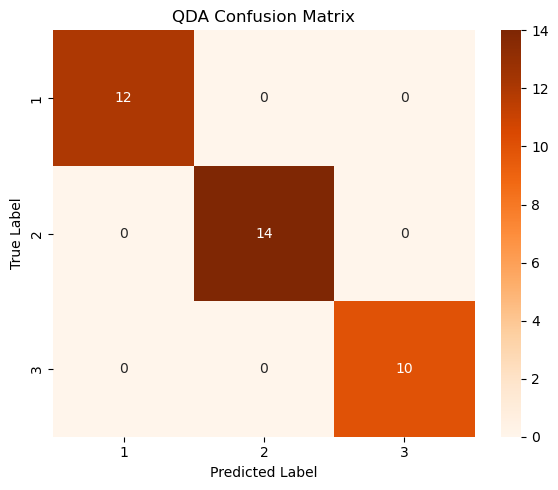

{'1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 12.0},
 '2': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 14.0},
 '3': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 10.0},
 'accuracy': 1.0,
 'macro avg': {'precision': 1.0,
  'recall': 1.0,
  'f1-score': 1.0,
  'support': 36.0},
 'weighted avg': {'precision': 1.0,
  'recall': 1.0,
  'f1-score': 1.0,
  'support': 36.0}}

In [10]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Step 4-2: QDA 모델링

# 모델 훈련
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# 예측
y_pred_qda = qda.predict(X_test)

# 성능 평가
conf_matrix_qda = confusion_matrix(y_test, y_pred_qda)
report_qda = classification_report(y_test, y_pred_qda, output_dict=True)

# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_qda, annot=True, fmt='d', cmap='Oranges', xticklabels=[1,2,3], yticklabels=[1,2,3])
plt.title("QDA Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

report_qda


## 성능 요약 (Test Set 기준)

| 클래스 | Precision | Recall | F1-score | Support |
| --- | --- | --- | --- | --- |
| **1** | 1.00 | 1.00 | 1.00 | 12 |
| **2** | 1.00 | 1.00 | 1.00 | 14 |
| **3** | 1.00 | 1.00 | 1.00 | 10 |
- **정확도 (Accuracy)**: **100%**
- **Macro 평균 F1-score**: **1.00**


## 해석

- **QDA는 모든 샘플을 완벽하게 분류**함
- 이는 각 클래스의 분포가 **정규분포를 따르고, 공분산 구조가 충분히 다르며**, QDA가 가정하는 조건에 매우 잘 맞기 때문이라고 판단.

→ QDA는 LDA보다 더 복잡한 경계를 학습하며, 이 데이터셋에서는 **과적합 없이 최적의 결과**를 달성함

## Step 4-3: SVM


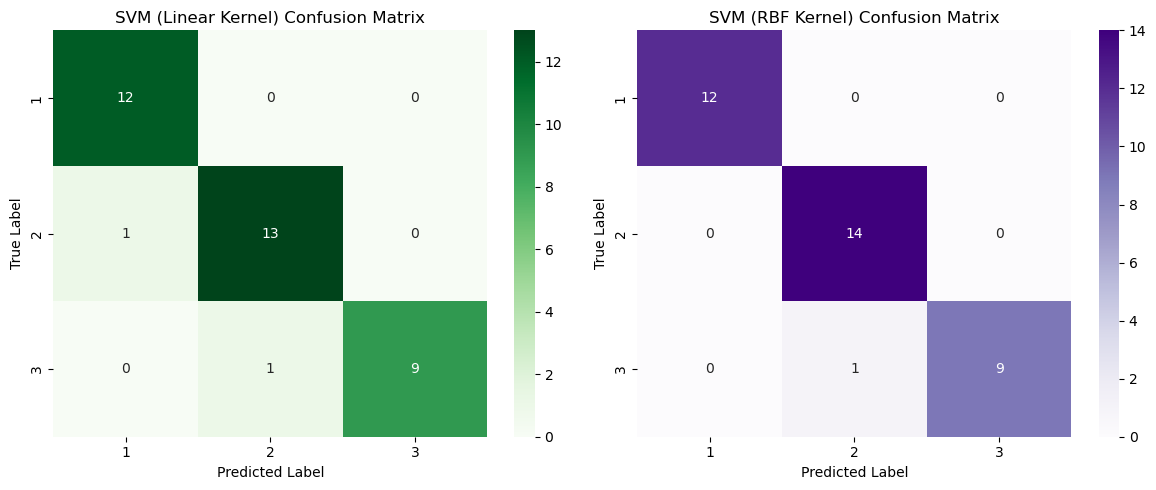

({'1': {'precision': 0.9230769230769231,
   'recall': 1.0,
   'f1-score': 0.96,
   'support': 12.0},
  '2': {'precision': 0.9285714285714286,
   'recall': 0.9285714285714286,
   'f1-score': 0.9285714285714286,
   'support': 14.0},
  '3': {'precision': 1.0,
   'recall': 0.9,
   'f1-score': 0.9473684210526315,
   'support': 10.0},
  'accuracy': 0.9444444444444444,
  'macro avg': {'precision': 0.9505494505494506,
   'recall': 0.942857142857143,
   'f1-score': 0.9453132832080201,
   'support': 36.0},
  'weighted avg': {'precision': 0.9465811965811967,
   'recall': 0.9444444444444444,
   'f1-score': 0.944269005847953,
   'support': 36.0}},
 {'1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 12.0},
  '2': {'precision': 0.9333333333333333,
   'recall': 1.0,
   'f1-score': 0.9655172413793104,
   'support': 14.0},
  '3': {'precision': 1.0,
   'recall': 0.9,
   'f1-score': 0.9473684210526315,
   'support': 10.0},
  'accuracy': 0.9722222222222222,
  'macro avg': {'precision': 0.9

In [11]:
from sklearn.svm import SVC

# Step 4-3: SVM 모델링 (linear & rbf kernel)

# SVM - 선형 커널
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_svm_linear = svm_linear.predict(X_test)
conf_matrix_svm_linear = confusion_matrix(y_test, y_pred_svm_linear)
report_svm_linear = classification_report(y_test, y_pred_svm_linear, output_dict=True)

# SVM - RBF 커널
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test)
conf_matrix_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf)
report_svm_rbf = classification_report(y_test, y_pred_svm_rbf, output_dict=True)

# 시각화 - 선형 커널
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_svm_linear, annot=True, fmt='d', cmap='Greens', xticklabels=[1,2,3], yticklabels=[1,2,3])
plt.title("SVM (Linear Kernel) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 시각화 - RBF 커널
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_svm_rbf, annot=True, fmt='d', cmap='Purples', xticklabels=[1,2,3], yticklabels=[1,2,3])
plt.title("SVM (RBF Kernel) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

report_svm_linear, report_svm_rbf


## 성능 요약

| 모델 유형 | 정확도 | 클래스 1 F1 | 클래스 2 F1 | 클래스 3 F1 |
| --- | --- | --- | --- | --- |
| **SVM (Linear)** | 94.4% | 0.96 | 0.93 | 0.95 |
| **SVM (RBF)** | 97.2% | 1.00 | 0.97 | 0.95 |

## 해석

- **선형 커널**도 상당히 높은 성능을 보이며 LDA와 유사한 수준
- **RBF 커널**은 비선형 경계를 반영할 수 있어, 클래스 2의 Recall을 **1.00**으로 향상시킴
- 클래스 3의 일부 샘플은 여전히 경계에서 오분류되는 경향이 있음 (Recall 0.90)

→ SVM은 **복잡한 경계에서도 안정적 분류가 가능한 강력한 모델**이며, RBF 커널 사용 시 정확도 및 F1-score가 가장 높게 나타남

## Step 4-4: KNN


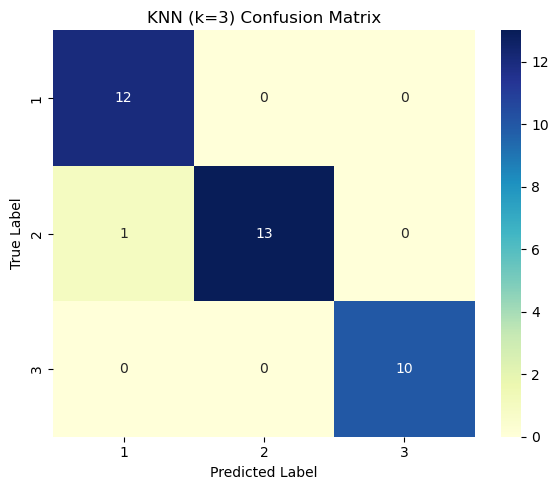

{'1': {'precision': 0.9230769230769231,
  'recall': 1.0,
  'f1-score': 0.96,
  'support': 12.0},
 '2': {'precision': 1.0,
  'recall': 0.9285714285714286,
  'f1-score': 0.9629629629629629,
  'support': 14.0},
 '3': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 10.0},
 'accuracy': 0.9722222222222222,
 'macro avg': {'precision': 0.9743589743589745,
  'recall': 0.9761904761904763,
  'f1-score': 0.974320987654321,
  'support': 36.0},
 'weighted avg': {'precision': 0.9743589743589745,
  'recall': 0.9722222222222222,
  'f1-score': 0.9722633744855966,
  'support': 36.0}}

In [12]:
from sklearn.neighbors import KNeighborsClassifier

# Step 4-4: KNN 모델링

# 기본 K 값으로 설정 (k=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# 성능 평가
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn, output_dict=True)

# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='YlGnBu', xticklabels=[1,2,3], yticklabels=[1,2,3])
plt.title("KNN (k=3) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

report_knn


## 성능 요약 (Test Set 기준)

| 클래스 | Precision | Recall | F1-score | Support |
| --- | --- | --- | --- | --- |
| **1** | 0.92 | 1.00 | 0.96 | 12 |
| **2** | 1.00 | 0.93 | 0.96 | 14 |
| **3** | 1.00 | 1.00 | 1.00 | 10 |
| **정확도** | - | - | **97.2%** | 36 |

## 해석

- **KNN은 간단한 거리 기반 알고리즘임에도 불구하고** 매우 우수한 성능을 보임
- 클래스 간 경계가 명확하고 데이터가 잘 정규화되어 있기 때문에 성능이 향상된 것으로 보임
- 특히 클래스 3은 모든 샘플을 완벽히 분류함 (F1 = 1.0)

## Step 4-5: k-means (비지도 클러스터링)

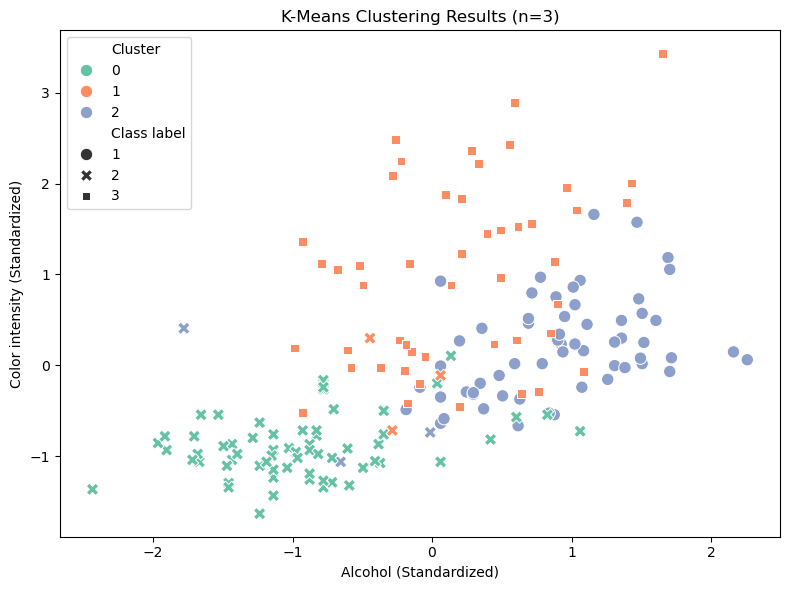

0.8974949815093207

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Step 4-5: k-means 클러스터링

# k-means 모델 생성 및 훈련
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
kmeans_labels = kmeans.labels_

# 클러스터 결과와 실제 클래스 레이블 비교 (Adjusted Rand Index 사용)
ari_score = adjusted_rand_score(y, kmeans_labels)

# 시각화
df_kmeans = pd.DataFrame(X_scaled, columns=X.columns)
df_kmeans['Cluster'] = kmeans_labels
df_kmeans['Class label'] = y

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_kmeans, x='Alcohol', y='Color intensity', hue='Cluster', palette='Set2', style='Class label', s=80)
plt.title("K-Means Clustering Results (n=3)")
plt.xlabel("Alcohol (Standardized)")
plt.ylabel("Color intensity (Standardized)")
plt.tight_layout()
plt.show()

ari_score


## 클러스터링 평가 지표

- **Adjusted Rand Index (ARI)**: **0.897**
    
    > 1에 가까울수록 클러스터링 결과가 실제 레이블 분포와 잘 일치함을 의미함

## 해석

- **k-means는 비지도 학습 알고리즘**임에도 불구하고, 실제 클래스와 거의 일치하는 결과를 도출
- 이는 와인 데이터셋의 클래스 간 특성이 매우 분명하고, 분포가 잘 분리되어 있음을 보여줌
- `Alcohol`과 `Color intensity` 축 기준의 시각화에서도 **클러스터와 실제 클래스 간 대응이 뚜렷하게 나타남**

---

# Step 5: 전체 성능 요약표 작성

In [14]:
import pandas as pd

# 각 모델의 성능 정리
model_performance = pd.DataFrame({
    'Model': ['LDA', 'QDA', 'SVM (Linear)', 'SVM (RBF)', 'KNN (k=3)'],
    'Accuracy': [
        report_lda['accuracy'],
        report_qda['accuracy'],
        report_svm_linear['accuracy'],
        report_svm_rbf['accuracy'],
        report_knn['accuracy']
    ],
    'Macro F1-score': [
        report_lda['macro avg']['f1-score'],
        report_qda['macro avg']['f1-score'],
        report_svm_linear['macro avg']['f1-score'],
        report_svm_rbf['macro avg']['f1-score'],
        report_knn['macro avg']['f1-score']
    ]
})

model_performance

,Model,Accuracy,Macro F1-score
0,LDA,0.944444,0.945313
1,QDA,1.000000,1.000000
2,SVM (Linear),0.944444,0.945313
3,SVM (RBF),0.972222,0.970962
4,KNN (k=3),0.972222,0.974321
